In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib import rcParams
import numpy as np

In [ ]:
df = pd.read_csv("depressionData.csv")

In [ ]:
df.head()

,Timestamp,Age,Feeling sad,Irritable towards people,Trouble sleeping at night,Problems concentrating or making decision,loss of appetite,Feeling of guilt,Problems of bonding with people,Suicide attempt,Depressed
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,No,Yes,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,Yes,Yes,No,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,No,Sometimes,No,Yes
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Maybe,No,No,Yes
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,No,Yes,No,Yes


In [ ]:
df.tail()

,Timestamp,Age,Feeling sad,Irritable towards people,Trouble sleeping at night,Problems concentrating or making decision,loss of appetite,Feeling of guilt,Problems of bonding with people,Suicide attempt,Depressed
1498,6/15/2022 0:35,30-35,Yes,No,Two or more days a week,No,No,Maybe,Sometimes,No,Yes
1499,6/15/2022 0:35,25-30,Sometimes,No,No,Often,No,Maybe,Yes,No,Yes
1500,6/15/2022 0:35,25-30,No,Sometimes,Two or more days a week,No,No,Yes,No,Not interested to say,No
1501,6/15/2022 0:36,25-30,No,Sometimes,Yes,Often,No,No,No,No,Yes
1502,6/15/2022 0:36,45-50,Sometimes,Sometimes,Two or more days a week,No,No,Maybe,No,No,No


In [ ]:
df.shape

(1503, 11)

In [ ]:
df.isnull().sum()

Timestamp                                     0
Age                                           0
Feeling sad                                   0
Irritable towards people                      6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
loss of appetite                              0
Feeling of guilt                              9
Problems of bonding with people               0
Suicide attempt                               0
Depressed                                     0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad                                1503 non-null   object
 3   Irritable towards people                   1497 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1491 non-null   object
 6   loss of appetite                           1503 non-null   object
 7   Feeling of guilt                           1494 non-null   object
 8   Problems of bonding with people            1503 non-null   object
 9   Suicide attempt                            1503 non-null   object
 10  Depressed                           

In [ ]:
df.describe()

,Timestamp,Age,Feeling sad,Irritable towards people,Trouble sleeping at night,Problems concentrating or making decision,loss of appetite,Feeling of guilt,Problems of bonding with people,Suicide attempt,Depressed
count,1503,1503,1503,1497,1503,1491,1503,1494,1503,1503,1503
unique,90,5,3,3,3,3,3,3,3,3,2
top,6/15/2022 22:24,40-45,Yes,Yes,Two or more days a week,No,No,No,No,No,Yes
freq,51,364,536,555,640,583,841,624,557,709,980


# Handling missing values

In [ ]:
df['Age'].value_counts()

40-45    364
35-40    349
30-35    338
45-50    271
25-30    181
Name: Age, dtype: int64

In [ ]:
df['Depressed'].value_counts()

Yes    980
No     523
Name: Depressed, dtype: int64

In [ ]:
df['loss of appetite'].value_counts()

No            841
Yes           343
Not at all    319
Name: loss of appetite, dtype: int64

In [ ]:
df['Problems concentrating or making decision'].fillna(df['Problems concentrating or making decision'].mode()[0], inplace=True)

In [ ]:
df.dropna(subset=['Irritable towards people'], inplace=True)

In [ ]:
df.shape

(1497, 11)

In [ ]:
df['loss of appetite'].fillna(df['loss of appetite'].mode()[0], inplace=True)

In [ ]:
df.dropna(subset=['Feeling of guilt'], inplace=True)

In [ ]:
df.shape

(1494, 11)

In [ ]:
df.isnull().sum()

Timestamp                                    0
Age                                          0
Feeling sad                                  0
Irritable towards people                     0
Trouble sleeping at night                    0
Problems concentrating or making decision    0
loss of appetite                             0
Feeling of guilt                             0
Problems of bonding with people              0
Suicide attempt                              0
Depressed                                    0
dtype: int64

In [ ]:
df['Problems concentrating or making decision'].value_counts()

No       586
Often    473
Yes      435
Name: Problems concentrating or making decision, dtype: int64

# Data visualisation

Text(0, 0.5, 'Distribution')

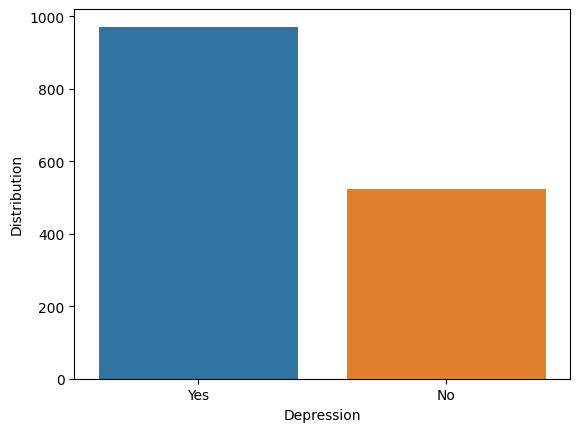

In [ ]:
_ = sns.countplot(x='Depressed', data=df)
plt.xlabel('Depression')
plt.ylabel('Distribution')

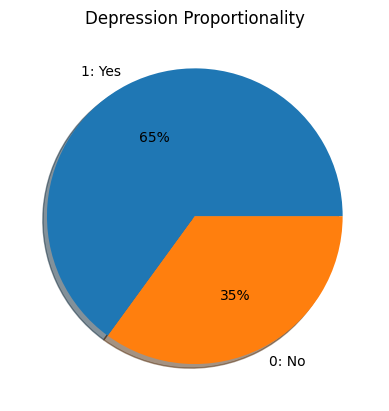

In [ ]:
plt.pie(df.Depressed.value_counts(),
        labels= ['1: Yes', '0: No'],
        autopct='%.f%%', shadow=True)
plt.title('Depression Proportionality')
plt.show()

40-45    358
35-40    346
30-35    338
45-50    271
25-30    181
Name: Age, dtype: int64


Text(0, 0.5, 'Distribution')

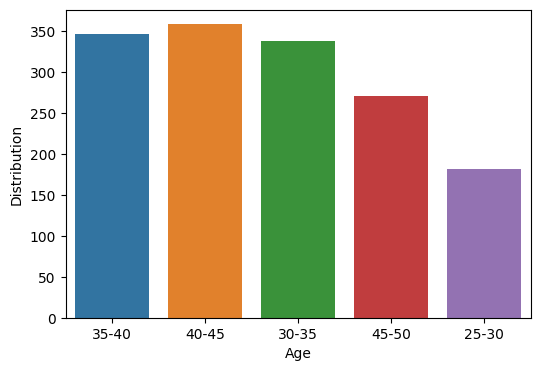

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Age'].value_counts())
_ = sns.countplot(x='Age', data=df)
plt.xlabel('Age')
plt.ylabel('Distribution')

Two or more days a week    637
Yes                        442
No                         415
Name: Trouble sleeping at night, dtype: int64


Text(0, 0.5, 'Distribution')

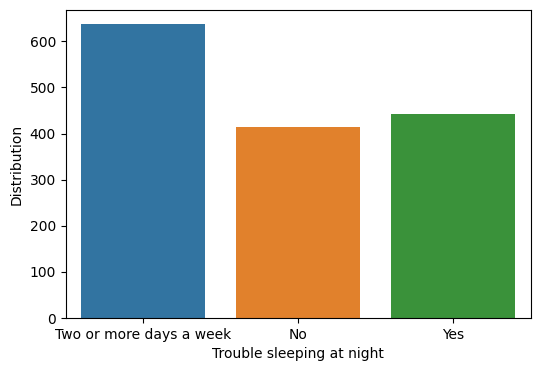

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Trouble sleeping at night'].value_counts())
_ = sns.countplot(x='Trouble sleeping at night', data=df)
plt.xlabel('Trouble sleeping at night')
plt.ylabel('Distribution')

No       624
Maybe    528
Yes      342
Name: Feeling of guilt, dtype: int64


Text(0, 0.5, 'Distribution')

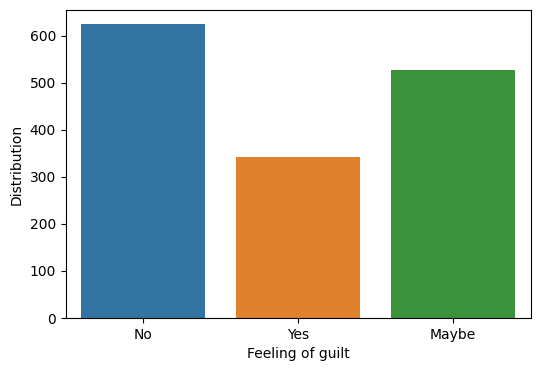

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Feeling of guilt'].value_counts())
_ = sns.countplot(x='Feeling of guilt', data=df)
plt.xlabel('Feeling of guilt')
plt.ylabel('Distribution')

Yes          552
No           499
Sometimes    443
Name: Irritable towards people, dtype: int64


Text(0, 0.5, 'Distribution')

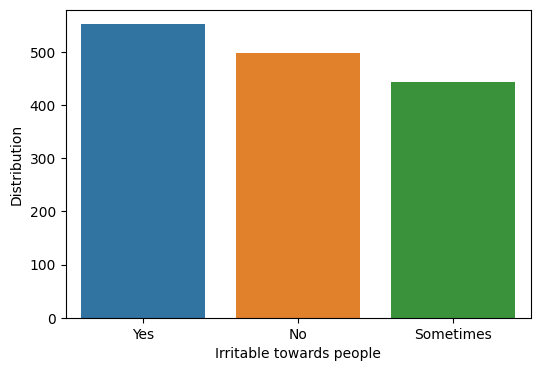

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Irritable towards people'].value_counts())
_ = sns.countplot(x='Irritable towards people', data=df)
plt.xlabel('Irritable towards people')
plt.ylabel('Distribution')

No                       703
Yes                      456
Not interested to say    335
Name: Suicide attempt, dtype: int64


Text(0, 0.5, 'Distribution')

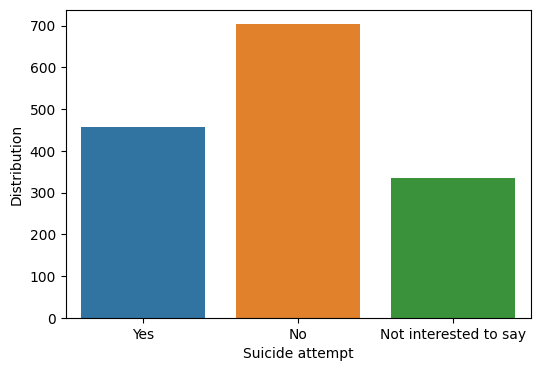

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Suicide attempt'].value_counts())
_ = sns.countplot(x='Suicide attempt', data=df)
plt.xlabel('Suicide attempt')
plt.ylabel('Distribution')

No       624
Maybe    528
Yes      342
Name: Feeling of guilt, dtype: int64


Text(0, 0.5, 'Distribution')

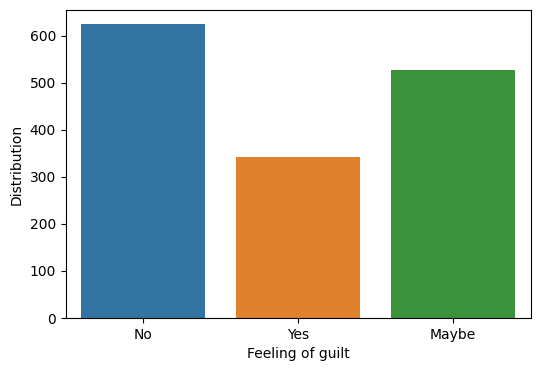

In [ ]:
plt.figure(figsize=(6, 4))
print(df['Feeling of guilt'].value_counts())
_ = sns.countplot(x='Feeling of guilt', data=df)
plt.xlabel('Feeling of guilt')
plt.ylabel('Distribution')

<Figure size 1000x1500 with 0 Axes>

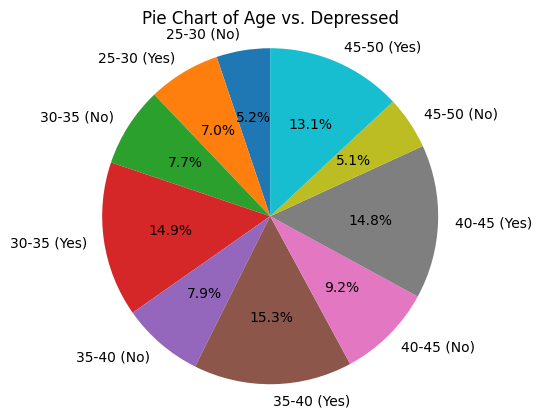

In [ ]:
plt.figure(figsize=(10, 15))
grouped_data = df.groupby(['Age', 'Depressed']).size().reset_index(name='count')

fig, ax = plt.subplots()
# autopct - automatic percentage display, startangle - determines the starting angle of the pie chart
ax.pie(grouped_data['count'], labels=grouped_data['Age'] + ' (' + grouped_data['Depressed'] + ')', autopct='%1.1f%%', startangle=90)
ax.axis('equal')
plt.title('Pie Chart of Age vs. Depressed')
plt.show()

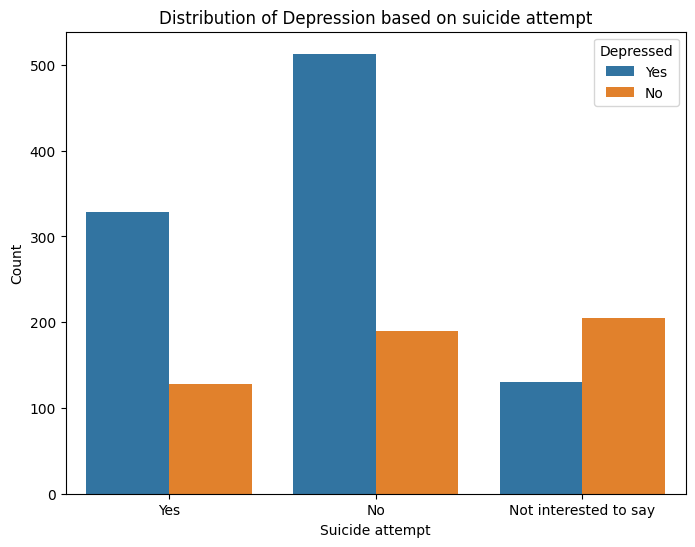

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Suicide attempt', hue='Depressed')
plt.title('Distribution of Depression based on suicide attempt')
plt.xlabel('Suicide attempt')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

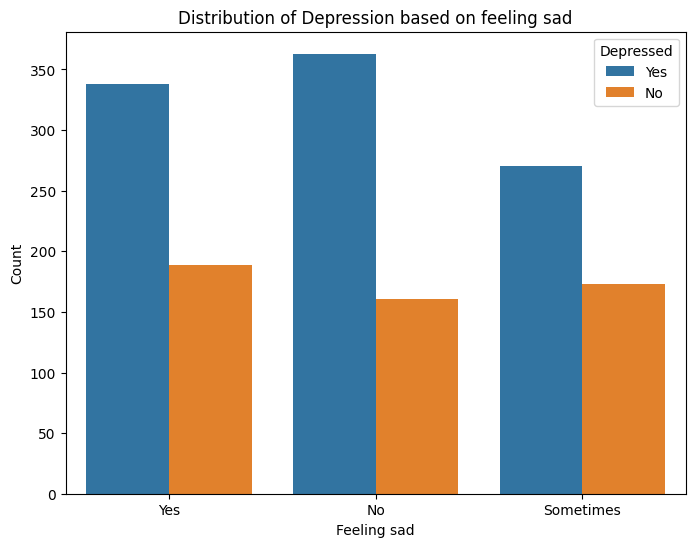

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Feeling sad', hue='Depressed')
plt.title('Distribution of Depression based on feeling sad')
plt.xlabel('Feeling sad')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

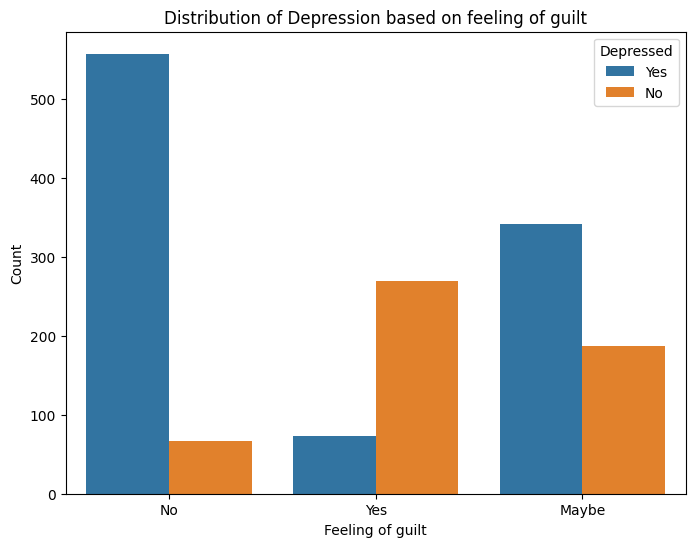

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Feeling of guilt', hue='Depressed')
plt.title('Distribution of Depression based on feeling of guilt')
plt.xlabel('Feeling of guilt')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

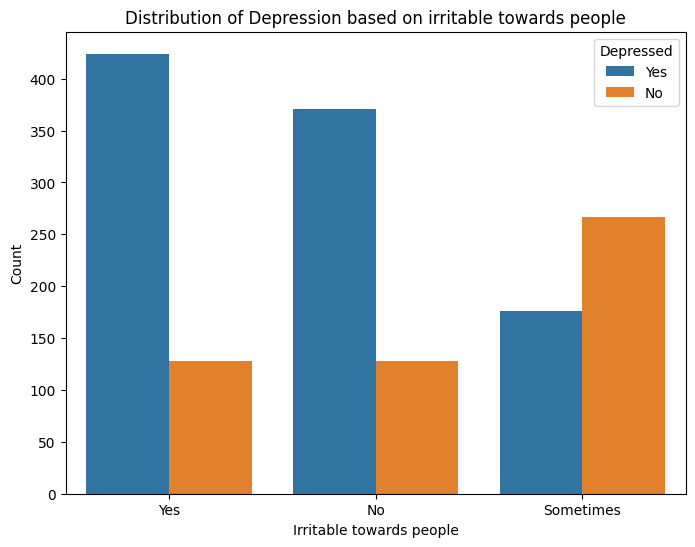

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Irritable towards people', hue='Depressed')
plt.title('Distribution of Depression based on irritable towards people')
plt.xlabel('Irritable towards people')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

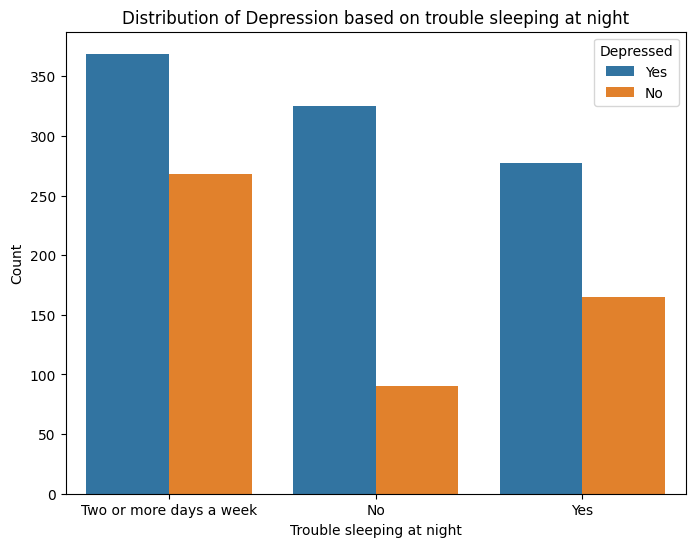

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Trouble sleeping at night', hue='Depressed')
plt.title('Distribution of Depression based on trouble sleeping at night')
plt.xlabel('Trouble sleeping at night')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

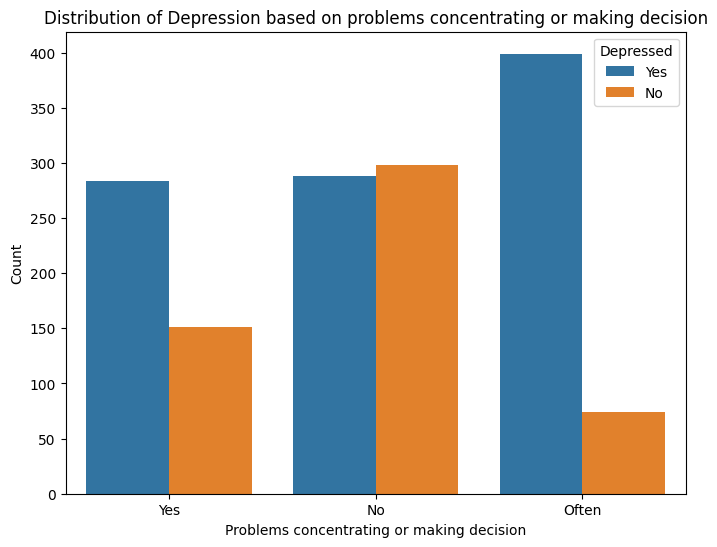

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Problems concentrating or making decision', hue='Depressed')
plt.title('Distribution of Depression based on problems concentrating or making decision')
plt.xlabel('Problems concentrating or making decision')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

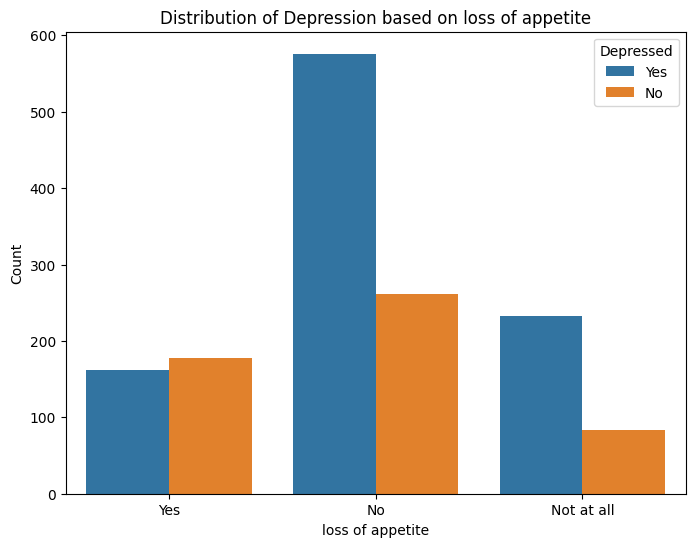

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='loss of appetite', hue='Depressed')
plt.title('Distribution of Depression based on loss of appetite')
plt.xlabel('loss of appetite')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

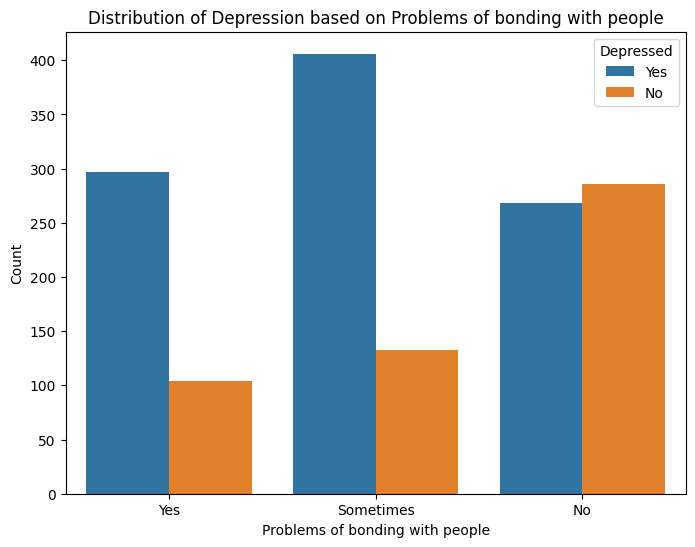

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Problems of bonding with people', hue='Depressed')
plt.title('Distribution of Depression based on Problems of bonding with people')
plt.xlabel('Problems of bonding with people')
plt.ylabel('Count')
plt.legend(title='Depressed', labels=['Yes', 'No'])
plt.show()

# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

columns = ['Feeling sad', 'Irritable towards people', 'Trouble sleeping at night', 'Problems concentrating or making decision', 'loss of appetite', 'Feeling of guilt', 'Problems of bonding with people', 'Suicide attempt']
label_encoder = LabelEncoder()
df[columns] = df[columns].apply(label_encoder.fit_transform)

Feeling sad: 2 - yes, 1 - no, 0 - sometimes

Irritable with people: 2 - yes, 0 - no, 1 - sometimes

Trouble sleeping : 1 - Two or more days a week, 0 - no, 2 - yes

Problems concentrating or making decision : 2 - yes, 0 - no, 1 - often

loss of appetite : 2 - yes, 0 - no

Feeling of guilt : 1 - no, 2 - yes, 0 - often

Problems of bonding with people	: 2 - yes, 1 - sometimes, 0 - no

Suicide attempt : 0 -no, 2 - yes, 1 - Not interested to say

Depresed : 1 - yes, 0 - no

In [ ]:
target_encoded = {'Yes': 1, 'No': 0}
df['Depressed'] = df['Depressed'].map(target_encoded)

In [ ]:
df['Depressed'].value_counts()

1    971
0    523
Name: Depressed, dtype: int64

In [ ]:
age_encoded = {'25-30':0, '30-35':1, '35-40':2, '40-45':3, '45-50':4}
df['Age'] = df['Age'].map(age_encoded)

In [ ]:
df['Age'].value_counts()

3    358
2    346
1    338
4    271
0    181
Name: Age, dtype: int64

In [ ]:
df.head()

,Timestamp,Age,Feeling sad,Irritable towards people,Trouble sleeping at night,Problems concentrating or making decision,loss of appetite,Feeling of guilt,Problems of bonding with people,Suicide attempt,Depressed
0,6/14/2022 20:02,2,2,2,1,2,2,1,2,2,1
1,6/14/2022 20:03,3,2,0,0,2,2,2,2,0,0
2,6/14/2022 20:04,2,2,0,2,2,2,1,1,0,1
3,6/14/2022 20:05,2,2,2,2,2,0,0,0,0,1
4,6/14/2022 20:06,3,2,0,1,2,0,1,2,0,1


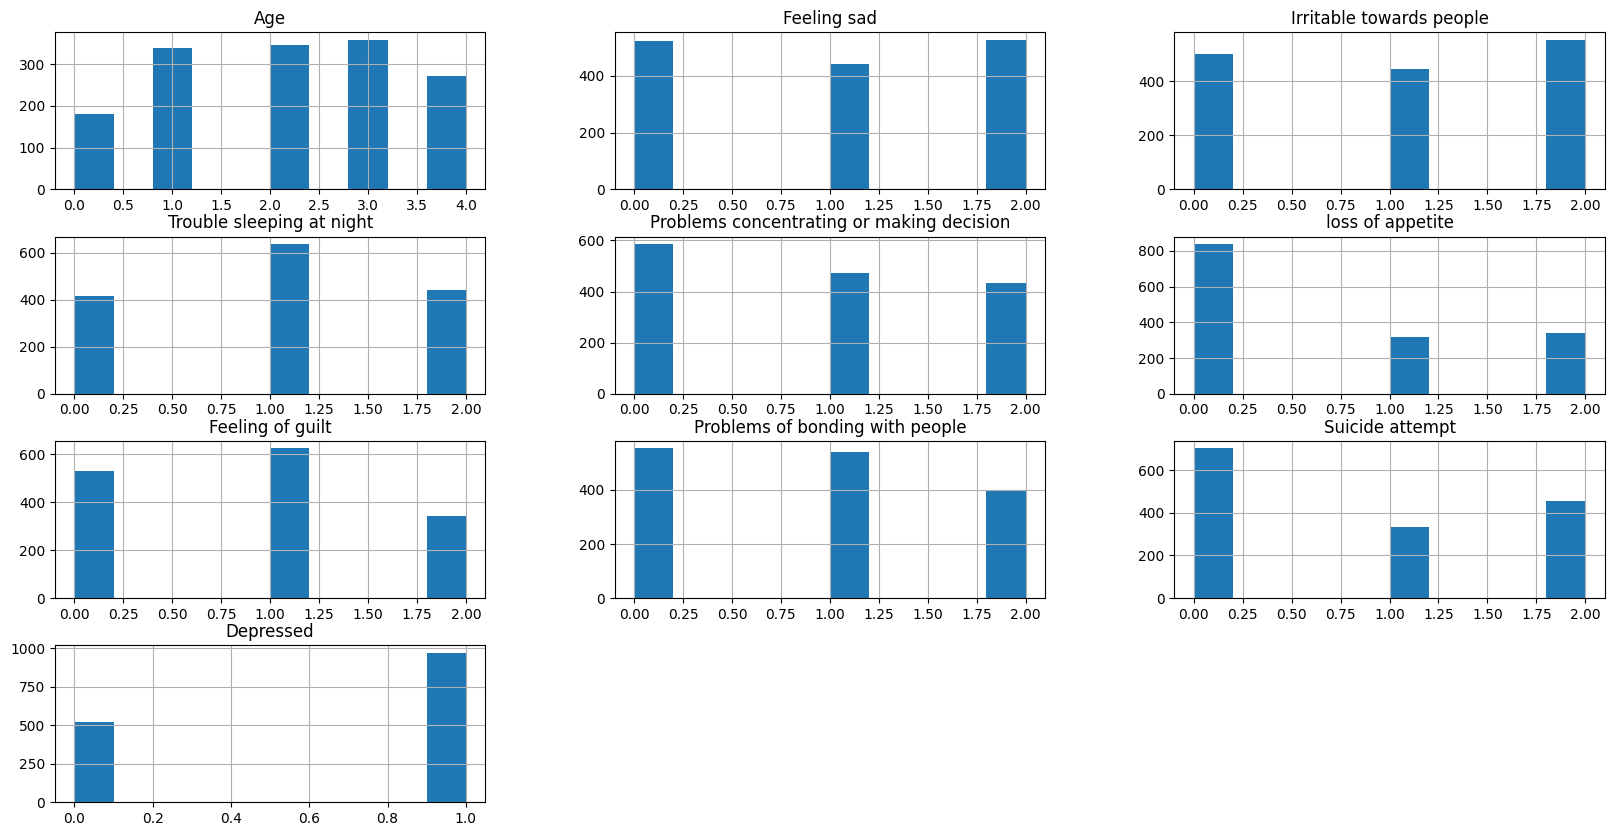

In [ ]:
plt.rcParams['figure.figsize'] = [20,10]
df.hist()
plt.show()

<ipython-input-19-42235fb2bd95>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot= True, cmap='plasma')


<Axes: >

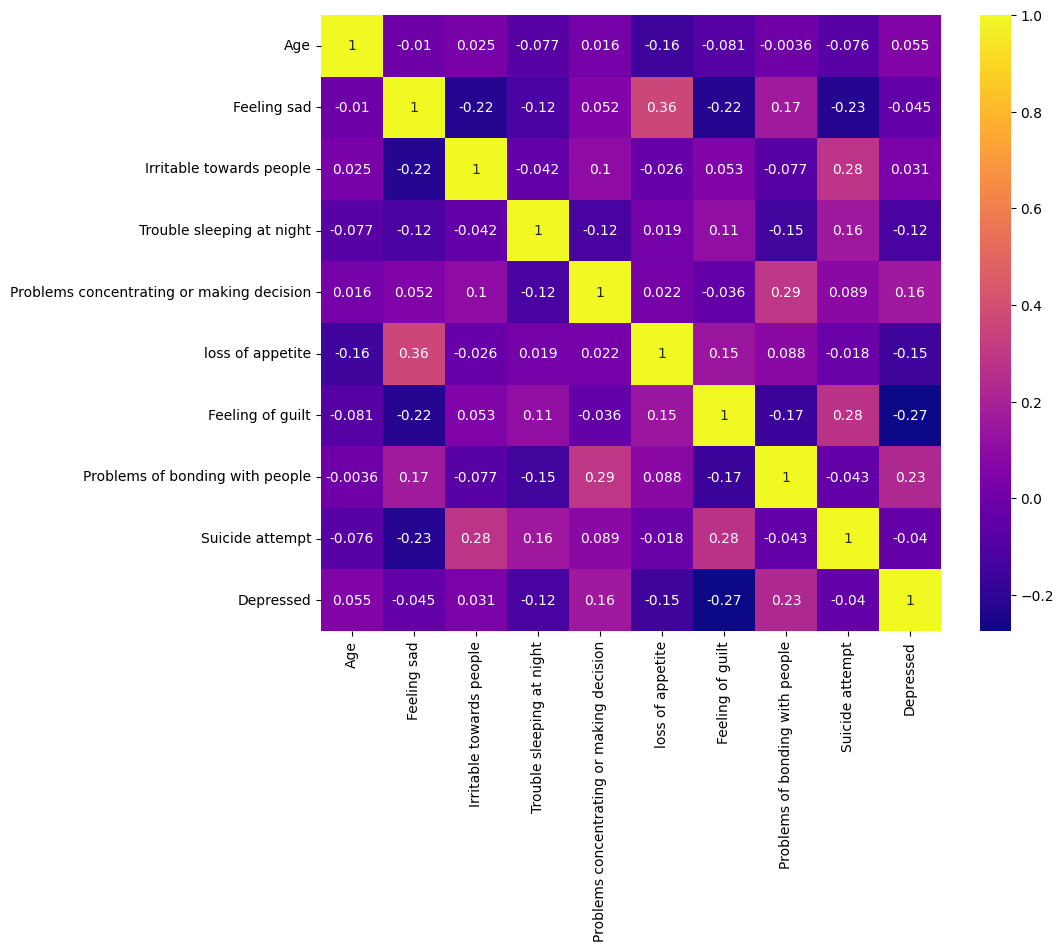

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot= True, cmap='plasma')

In [ ]:
df1 = df.drop(['Timestamp'], axis=1)
df1.head()

,Age,Feeling sad,Irritable towards people,Trouble sleeping at night,Problems concentrating or making decision,loss of appetite,Feeling of guilt,Problems of bonding with people,Suicide attempt,Depressed
0,2,2,2,1,2,2,1,2,2,1
1,3,2,0,0,2,2,2,2,0,0
2,2,2,0,2,2,2,1,1,0,1
3,2,2,2,2,2,0,0,0,0,1
4,3,2,0,1,2,0,1,2,0,1


In [ ]:
df1.shape

(1494, 10)

In [ ]:
df1.dtypes

Age                                          int64
Feeling sad                                  int64
Irritable towards people                     int64
Trouble sleeping at night                    int64
Problems concentrating or making decision    int64
loss of appetite                             int64
Feeling of guilt                             int64
Problems of bonding with people              int64
Suicide attempt                              int64
Depressed                                    int64
dtype: object

# Train Test Split

In [ ]:
X = df1.drop(['Depressed'], axis=1)
y = df1['Depressed']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1045, 9)
(449, 9)
(1045,)
(449,)


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model_lg = LogisticRegression(random_state=0)
model_lg.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
pred_lg = model_lg.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
lg = accuracy_score(y_test, pred_lg)
print(lg)

0.7193763919821826


In [ ]:
from sklearn.metrics import log_loss
loss = log_loss(y_test, pred_lg)
print("Log Loss: ", loss)

Log Loss:  10.114700060197686


In [ ]:
print(classification_report(y_test,pred_lg))

              precision    recall  f1-score   support

           0       0.69      0.41      0.52       163
           1       0.73      0.90      0.80       286

    accuracy                           0.72       449
   macro avg       0.71      0.65      0.66       449
weighted avg       0.71      0.72      0.70       449



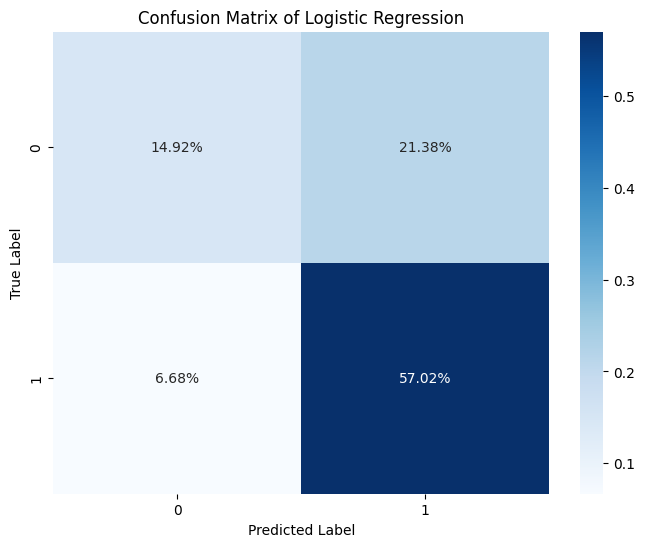

In [ ]:
cm = confusion_matrix(y_test, pred_lg, normalize='all')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()

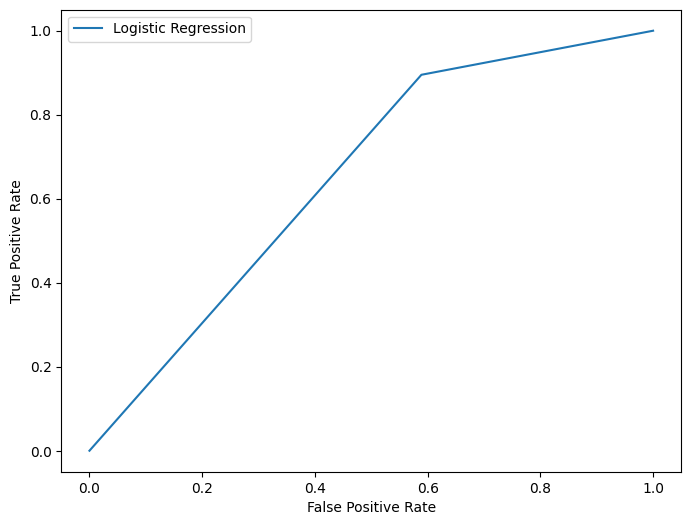

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_lg)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_kn = KNeighborsClassifier()
model_kn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_kn = model_kn.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
kn = accuracy_score(y_test, pred_kn)
print(kn)

0.8663697104677061


In [ ]:
from sklearn.metrics import log_loss

In [ ]:
loss_kn = log_loss(y_test, pred_kn)
print("Log Loss: ", loss_kn)

Log Loss:  4.816523838189375


In [ ]:
print(classification_report(y_test,pred_kn))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       163
           1       0.87      0.92      0.90       286

    accuracy                           0.87       449
   macro avg       0.86      0.84      0.85       449
weighted avg       0.87      0.87      0.86       449



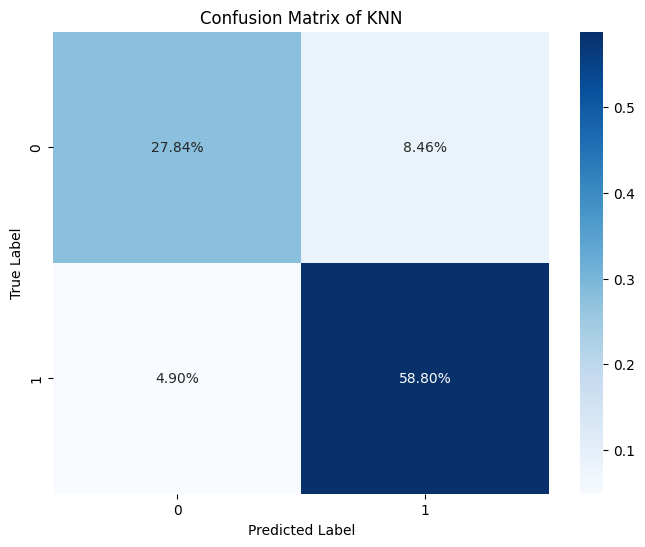

In [ ]:
cm = confusion_matrix(y_test, pred_kn, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNN')
plt.show()

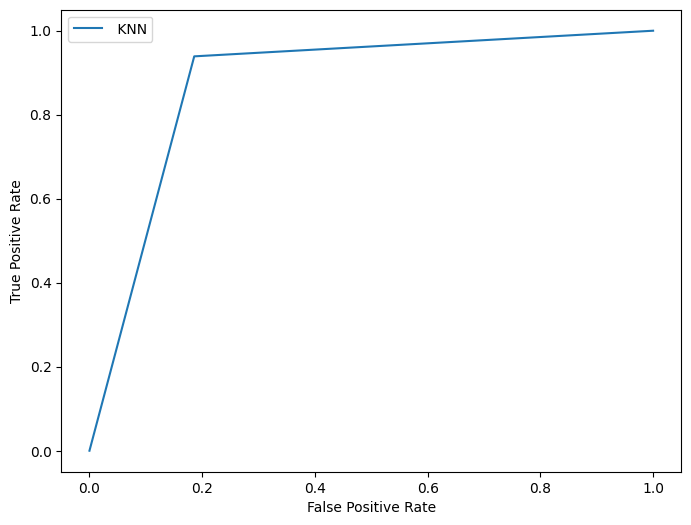

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_kn)
plt.plot(fpr_lr, tpr_lr, label=' KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# SVM

In [ ]:
from sklearn import svm
model_svm = svm.SVC(kernel="linear")
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
pred_svm = model_svm.predict(X_test)

In [ ]:
sv = accuracy_score(y_test, pred_svm)
print(sv)

0.6592427616926503


In [ ]:
loss_svm = log_loss(y_test, pred_svm)
print("Log Loss: ", loss_svm)

Log Loss:  12.282135787382904


In [ ]:
print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

           0       0.58      0.22      0.32       163
           1       0.67      0.91      0.77       286

    accuracy                           0.66       449
   macro avg       0.63      0.56      0.55       449
weighted avg       0.64      0.66      0.61       449



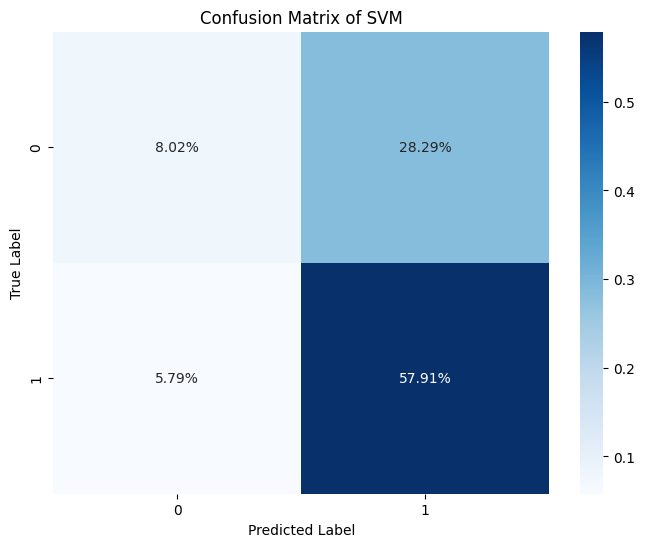

In [ ]:
cm = confusion_matrix(y_test, pred_svm, normalize='all')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of SVM')
plt.show()

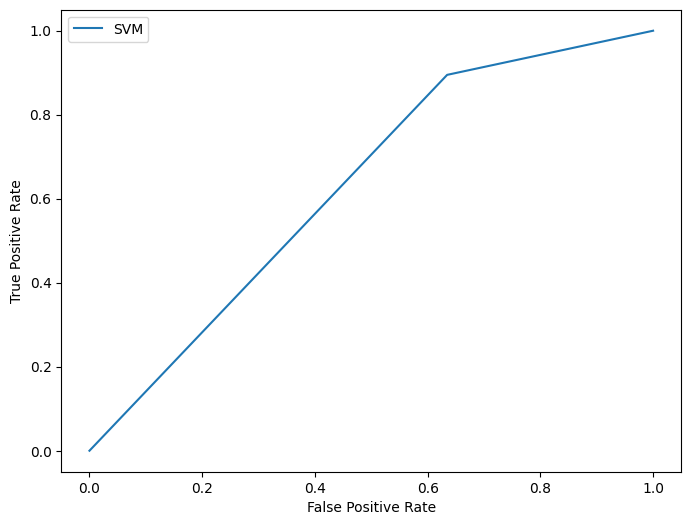

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_svm)
plt.plot(fpr_lr, tpr_lr, label='SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
pred_nb = model_nb.predict(X_test)

In [ ]:
nb = accuracy_score(y_test, pred_nb)
print(nb)

0.779510022271715


In [ ]:
loss_nb = log_loss(y_test, pred_nb)
print("Log Loss: ", loss_nb)

Log Loss:  7.947264333012468


In [ ]:
print(classification_report(y_test,pred_nb))

              precision    recall  f1-score   support

           0       0.76      0.58      0.66       163
           1       0.79      0.90      0.84       286

    accuracy                           0.78       449
   macro avg       0.77      0.74      0.75       449
weighted avg       0.78      0.78      0.77       449



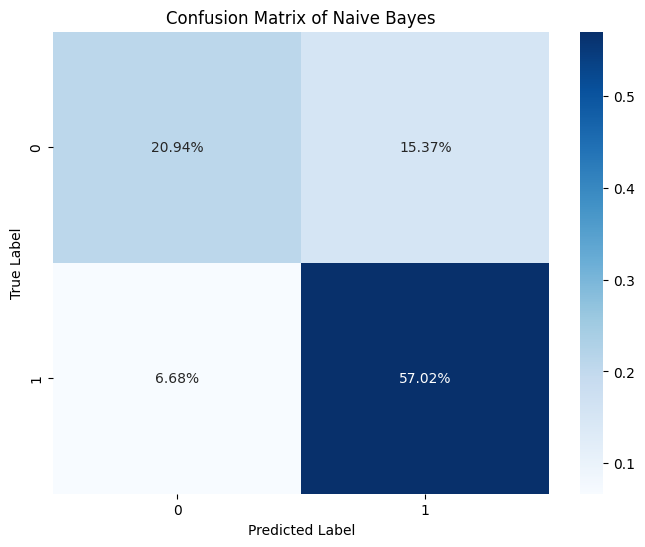

In [ ]:
cm = confusion_matrix(y_test, pred_nb, normalize='all')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Naive Bayes')
plt.show()

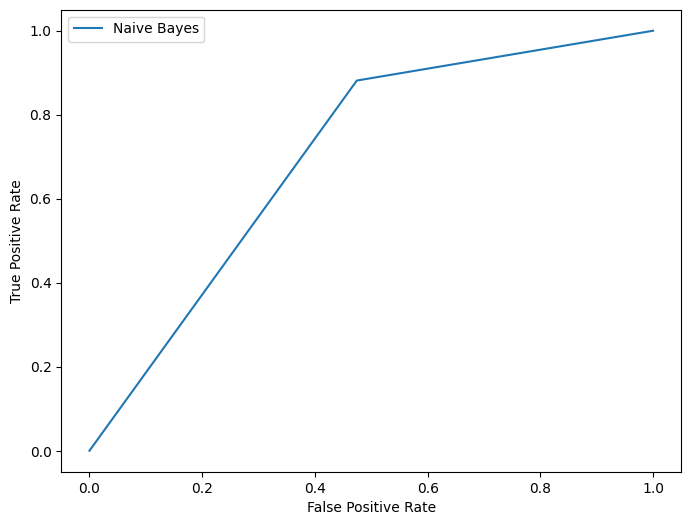

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_nb)
plt.plot(fpr_lr, tpr_lr, label='Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_classifier = DecisionTreeClassifier(random_state=42)
decision_tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
pred_dt = decision_tree_classifier.predict(X_test)

In [ ]:
dt = accuracy_score(y_test, pred_dt)
print(dt)

0.977728285077951


In [ ]:
loss_dt = log_loss(y_test, pred_dt)
print("Log Loss: ", loss_dt)

Log Loss:  0.8027539730315626


In [ ]:
print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       163
           1       1.00      0.97      0.98       286

    accuracy                           0.98       449
   macro avg       0.97      0.98      0.98       449
weighted avg       0.98      0.98      0.98       449



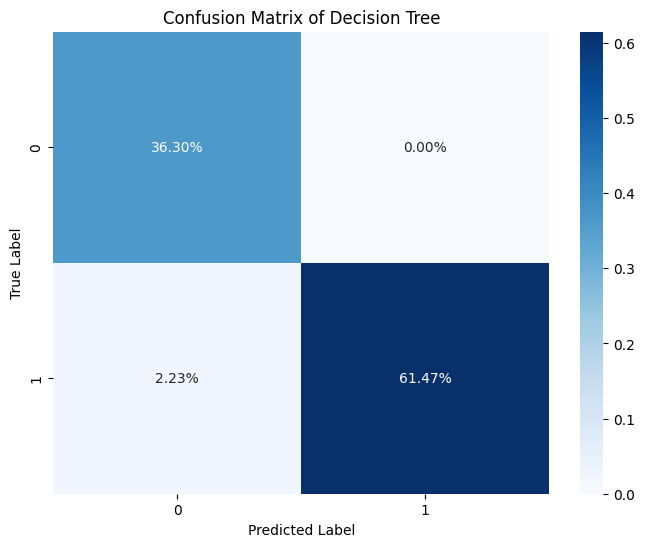

In [ ]:
cm = confusion_matrix(y_test, pred_dt, normalize='all')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Decision Tree')
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred_rf = model_rf.predict(X_test)

In [ ]:
rf = accuracy_score(y_test, pred_rf)
print(rf)

0.9732739420935412


In [ ]:
loss_rf = log_loss(y_test, pred_rf)
print("Log Loss: ", loss_rf)

Log Loss:  0.9633047676378751


In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       163
           1       0.98      0.99      0.99       286

    accuracy                           0.98       449
   macro avg       0.98      0.98      0.98       449
weighted avg       0.98      0.98      0.98       449



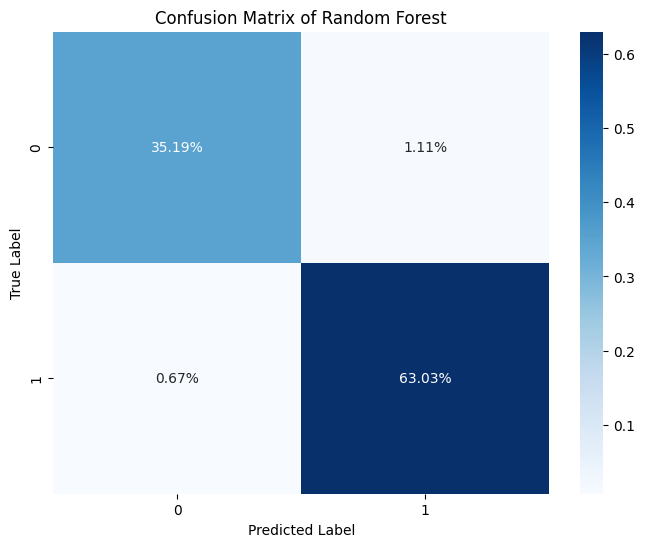

In [ ]:
cm = confusion_matrix(y_test, pred_rf, normalize='all')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Random Forest')
plt.show()

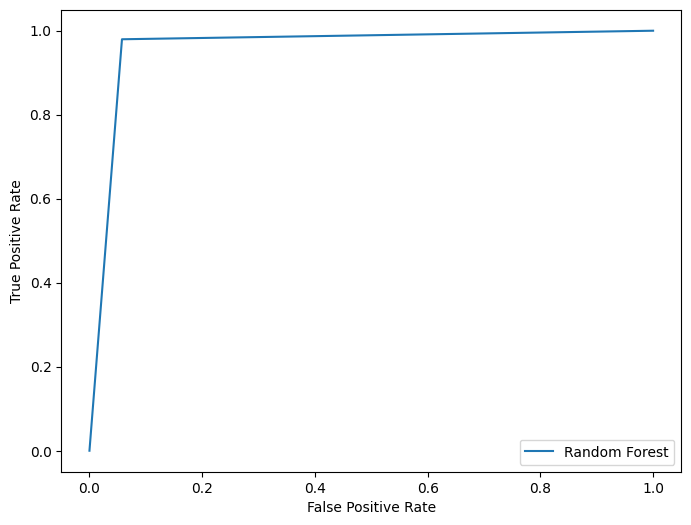

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_rf)
plt.plot(fpr_lr, tpr_lr, label='Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# XGBoost

In [ ]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(max_depth= 10, n_estimators= 50, random_state= 0,  learning_rate= 0.05, n_jobs=5)

In [ ]:
# Training Model
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=5,
              num_parallel_tree=None, random_state=0, ...)

In [ ]:
pred_xgb = model_xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

xgb = accuracy_score(y_test, pred_xgb)
print(xgb)

0.933184855233853


In [ ]:
loss_xgb = log_loss(y_test, pred_xgb)
print("Log Loss: ", loss_xgb)

Log Loss:  2.4082619190946875


In [ ]:
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       163
           1       0.95      0.96      0.95       286

    accuracy                           0.94       449
   macro avg       0.94      0.93      0.93       449
weighted avg       0.94      0.94      0.94       449



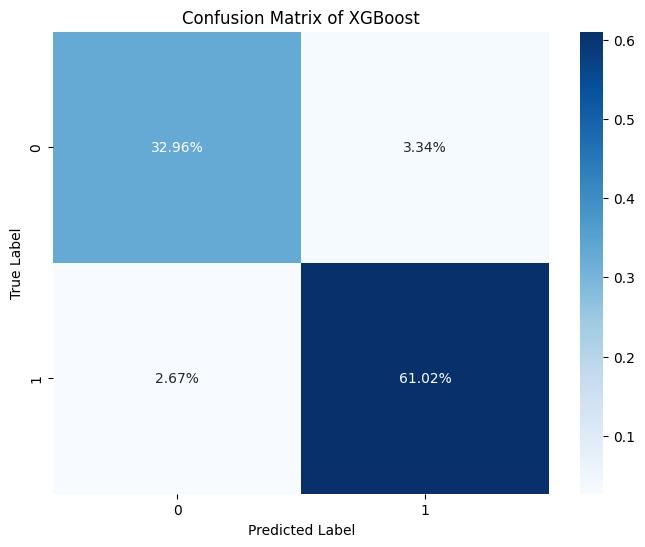

In [ ]:
cm = confusion_matrix(y_test, pred_xgb, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of XGBoost')
plt.show()

# AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_classifier = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_classifier.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [ ]:
pred_ada = adaboost_classifier.predict(X_test)

In [ ]:
ada = accuracy_score(y_test, pred_ada)
print(ada)

0.8106904231625836


In [ ]:
loss_ada = log_loss(y_test, pred_ada)
print("Log Loss: ", loss_ada)

Log Loss:  6.823408770768281


In [ ]:
print(classification_report(y_test,pred_ada))

              precision    recall  f1-score   support

           0       0.76      0.69      0.73       163
           1       0.83      0.88      0.86       286

    accuracy                           0.81       449
   macro avg       0.80      0.79      0.79       449
weighted avg       0.81      0.81      0.81       449



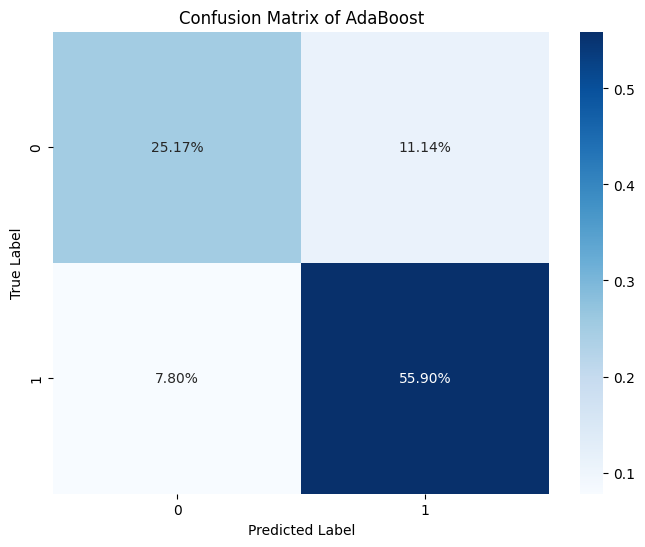

In [ ]:
cm = confusion_matrix(y_test, pred_ada, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of AdaBoost')
plt.show()

# GradientBoost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gradient_boosting_classifier.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
pred_gb = gradient_boosting_classifier.predict(X_test)

In [ ]:
gb = accuracy_score(y_test, pred_gb)
print(gb)

0.89086859688196


In [ ]:
loss_gb = log_loss(y_test, pred_gb)
print("Log Loss: ", loss_gb)

Log Loss:  3.9334944678546564


In [ ]:
print(classification_report(y_test,pred_gb))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       163
           1       0.90      0.93      0.92       286

    accuracy                           0.89       449
   macro avg       0.88      0.88      0.88       449
weighted avg       0.89      0.89      0.89       449



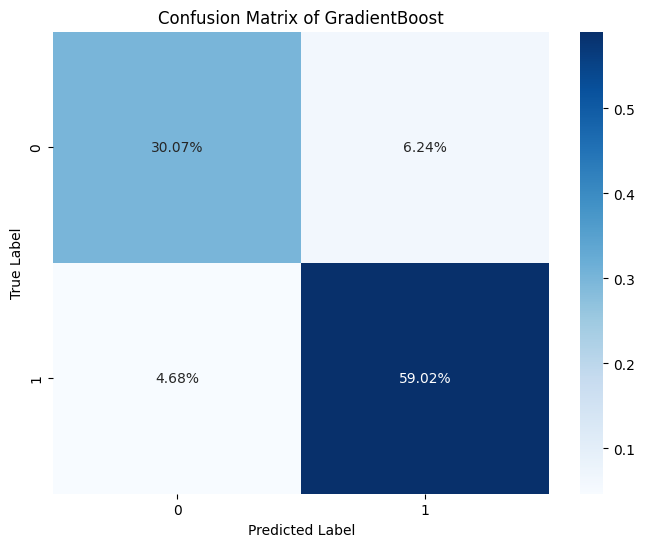

In [ ]:
cm = confusion_matrix(y_test, pred_gb, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of GradientBoost')
plt.show()

# Ensemble Method

In [ ]:
from sklearn.ensemble import VotingClassifier

# Create the Voting Classifier with the individual classifiers
voting_classifier = VotingClassifier(
    estimators=[
        ('xgboost', model_xgb),
        ('random forest', model_rf),
        ('decision tree', decision_tree_classifier)
    ],
    voting='hard'  # 'hard' for majority voting or 'soft' for weighted voting based on probabilities
)

In [ ]:
# Train the voting classifier on the scaled training data
voting_classifier.fit(X_train, y_train)

# Make predictions on the scaled test data
prediction = voting_classifier.predict(X_test)

In [ ]:
# Evaluate the model on the test set
ens = accuracy_score(y_test, prediction)
print("Voting Classifier Accuracy:", ens*100)

Voting Classifier Accuracy: 96.65924276169265


In [ ]:
loss_en1 = log_loss(y_test, prediction)
print("Log Loss: ", loss_en1)

Log Loss:  1.0435801649410312


In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       163
           1       0.99      0.97      0.98       286

    accuracy                           0.97       449
   macro avg       0.97      0.97      0.97       449
weighted avg       0.97      0.97      0.97       449



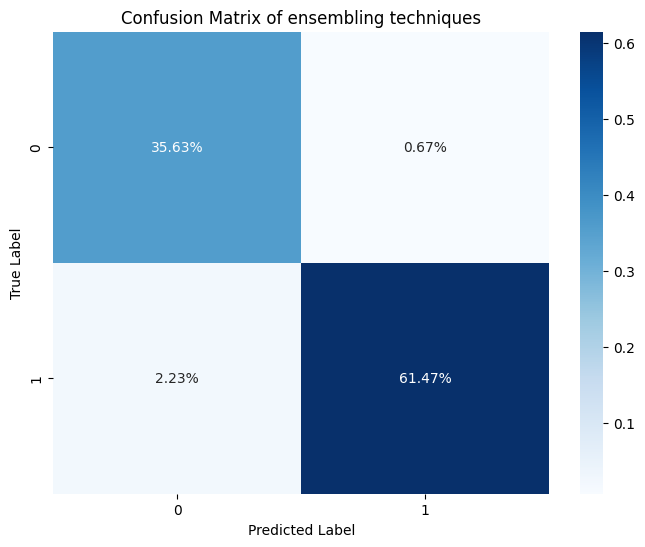

In [ ]:
cm = confusion_matrix(y_test, prediction, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of ensembling techniques')
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

# Create the Voting Classifier with the individual classifiers
voting_classifier2 = VotingClassifier(
    estimators=[
        ('xgboost', model_xgb),
        ('random forest', model_rf),
        ('decision tree', decision_tree_classifier),
        ('knn', model_kn)
    ],
    voting='hard'  # Use 'hard' for majority voting or 'soft' for weighted voting based on probabilities
)

In [ ]:
# Train the voting classifier on the scaled training data
voting_classifier2.fit(X_train, y_train)

# Make predictions on the scaled test data
prediction2 = voting_classifier2.predict(X_test)

In [ ]:
# Evaluate the model on the test set
voting_accuracy2 = accuracy_score(y_test, prediction2)
print("Voting Classifier Accuracy:", voting_accuracy2*100)

Voting Classifier Accuracy: 97.10467706013362


In [ ]:
loss_en2 = log_loss(y_test, prediction2)
print("Log Loss: ", loss_en2)

Log Loss:  1.0435801649410312


In [ ]:
print(classification_report(y_test, prediction2))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       163
           1       0.99      0.97      0.98       286

    accuracy                           0.97       449
   macro avg       0.97      0.97      0.97       449
weighted avg       0.97      0.97      0.97       449



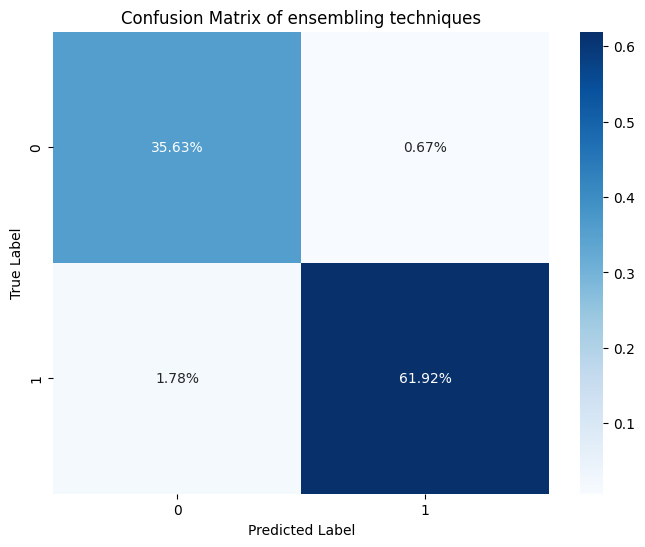

In [ ]:
cm = confusion_matrix(y_test, prediction2, normalize='all')  # Normalize the confusion matrix to sum to 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues')  # Use fmt='.2%' to format as percentages with two decimal places
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of ensembling techniques')
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

# Create the Voting Classifier with the individual classifiers
voting_classifier3 = VotingClassifier(
    estimators=[
        ('xgboost', model_xgb),
        ('random forest', model_rf),
        ('decision tree', decision_tree_classifier),
        ('knn', model_kn),
         ('gradient boost', gradient_boosting_classifier)
    ],
    voting='hard'  # Use 'hard' for majority voting or 'soft' for weighted voting based on probabilities
)

In [ ]:
# Train the voting classifier on the scaled training data
voting_classifier3.fit(X_train, y_train)

# Make predictions on the scaled test data
prediction3 = voting_classifier3.predict(X_test)

In [ ]:
# Evaluate the model on the test set
voting_accuracy3 = accuracy_score(y_test, prediction3)
print("Voting Classifier Accuracy:", voting_accuracy3*100)

Voting Classifier Accuracy: 95.99109131403118


# Comparison

,Model,Accuracy_score
5,Random Forest,0.982183
4,Decision Tree,0.977728
9,Ensemble Method,0.971047
6,XGBoost,0.933185
8,GradientBoost,0.890869
1,KNN,0.866370
7,AdaBoost,0.810690
3,Naive Bayes,0.779510
0,Logistic Regression,0.719376
2,SVM,0.659243


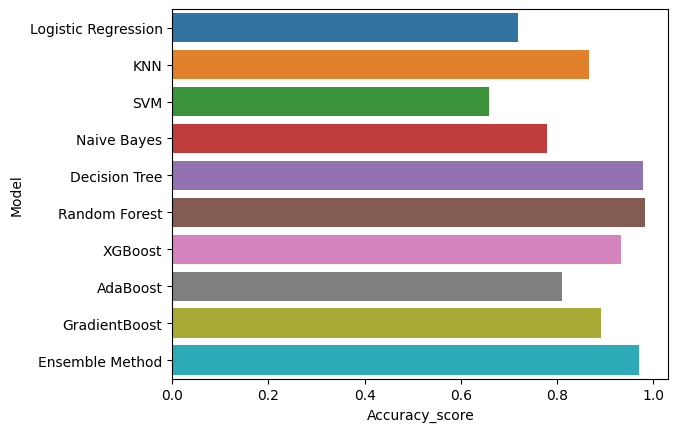

In [ ]:
models = pd.DataFrame({
    'Model':['Logistic Regression', 'KNN', 'SVM', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost', 'AdaBoost', 'GradientBoost', 'Ensemble Method'],
    'Accuracy_score' :[lg, kn, sv, nb, dt, rf, xgb, ada, gb, ens]
})
models
sns.barplot(x='Accuracy_score', y='Model', data=models)

models.sort_values(by='Accuracy_score', ascending=False)